distributie
Promovare
1    250
0    250
Name: count, dtype: int64
datele sunt balansate


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta_studiu, beta_somn]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.
There were 355 divergences after tuning. Increase `target_accept` or reparameterize.


rezumat parametrii
               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha       -29.157  5.144 -39.053  -20.057      0.217    0.165     531.0   
beta_studiu   2.356  0.890   0.799    4.060      0.031    0.020     859.0   
beta_somn     3.100  0.830   1.510    4.566      0.032    0.021     632.0   

             ess_tail  r_hat  
alpha           338.0   1.01  
beta_studiu    1029.0   1.01  
beta_somn       321.0   1.00  


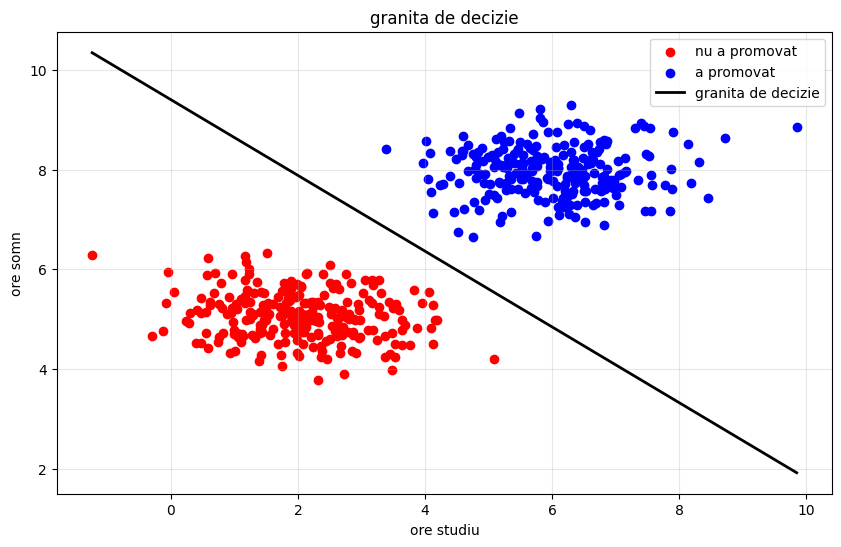

analiza influenta
coeficient ore studiu: 2.356
coeficient ore somn: 3.100
orele de somn influenteaza mai mult promovabilitatea


In [ ]:
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import numpy as np

#a

df = pd.read_csv('date_promovare_examen.csv')

counts = df['Promovare'].value_counts()
print("distributie")
print(counts)

is_balanced = abs(counts[0] - counts[1]) < (0.1 * len(df))
if is_balanced:
    print("datele sunt balansate")
else:
    print("datele nu sunt balansate")

X_studiu = df['Ore_Studiu'].values
X_somn = df['Ore_Somn'].values
y_obs = df['Promovare'].values

with pm.Model() as model_logistic:
    alpha = pm.Normal('alpha', mu=0, sigma=10)
    beta_studiu = pm.Normal('beta_studiu', mu=0, sigma=10)
    beta_somn = pm.Normal('beta_somn', mu=0, sigma=10)
    
    mu = alpha + beta_studiu * X_studiu + beta_somn * X_somn #nr totatl de ore
    
    p = pm.math.sigmoid(mu) #transf in prob
    
    y = pm.Bernoulli('y', p=p, observed=y_obs) #comparam p cu ce s a intamplat defapt

    idata = pm.sample(1000, return_inferencedata=True, progressbar=True)

print("rezumat parametrii")
summary = az.summary(idata)
print(summary)

#b

post = az.summary(idata)['mean']
alpha_mean = post['alpha']
beta_studiu_mean = post['beta_studiu']
beta_somn_mean = post['beta_somn']

x_plot = np.linspace(df['Ore_Studiu'].min(), df['Ore_Studiu'].max(), 100)
y_plot = -(alpha_mean + beta_studiu_mean * x_plot) / beta_somn_mean  #de la formula a+b1x+b2y=0

plt.figure(figsize=(10, 6))

plt.scatter(df[df['Promovare']==0]['Ore_Studiu'], df[df['Promovare']==0]['Ore_Somn'], 
            color='red', label='nu a promovat')


plt.scatter(df[df['Promovare']==1]['Ore_Studiu'], df[df['Promovare']==1]['Ore_Somn'], 
            color='blue', label='a promovat')

plt.plot(x_plot, y_plot, color='black', linewidth=2, label='granita de decizie')

plt.xlabel('ore studiu')
plt.ylabel('ore somn')
plt.title('granita de decizie')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#c

print("analiza influenta")
print(f"coeficient ore studiu: {beta_studiu_mean:.3f}")
print(f"coeficient ore somn: {beta_somn_mean:.3f}")

if abs(beta_studiu_mean) > abs(beta_somn_mean):
    print("orele de studiu influenteaza mai mult promovabilitatea")
else:
    print("orele de somn influenteaza mai mult promovabilitatea")